In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [8]:
# Make the corner plot for the MCMC results
system_name = 'HE0435'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [9]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,0.694699,260.5266,-1.169113,-0.599446,0.362564,13.83561
1,0.740880,260.5664,-1.169266,-0.600101,0.362538,13.82776
2,1.024208,260.5700,-1.168085,-0.598650,0.364263,13.83103
3,2.975227,260.6277,-1.168382,-0.595364,0.367339,13.83055
4,3.923858,260.8833,-1.169053,-0.595583,0.365390,13.83069
...,...,...,...,...,...,...
3521,1.811311,260.6894,-1.167242,-0.602937,0.370530,13.85606
3522,5.428082,261.0891,-1.169094,-0.608066,0.370321,13.85698
3523,10.475810,261.0266,-1.168756,-0.614597,0.368111,13.85477
3524,7.682265,261.0634,-1.169408,-0.611248,0.368221,13.84066


In [10]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [16]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

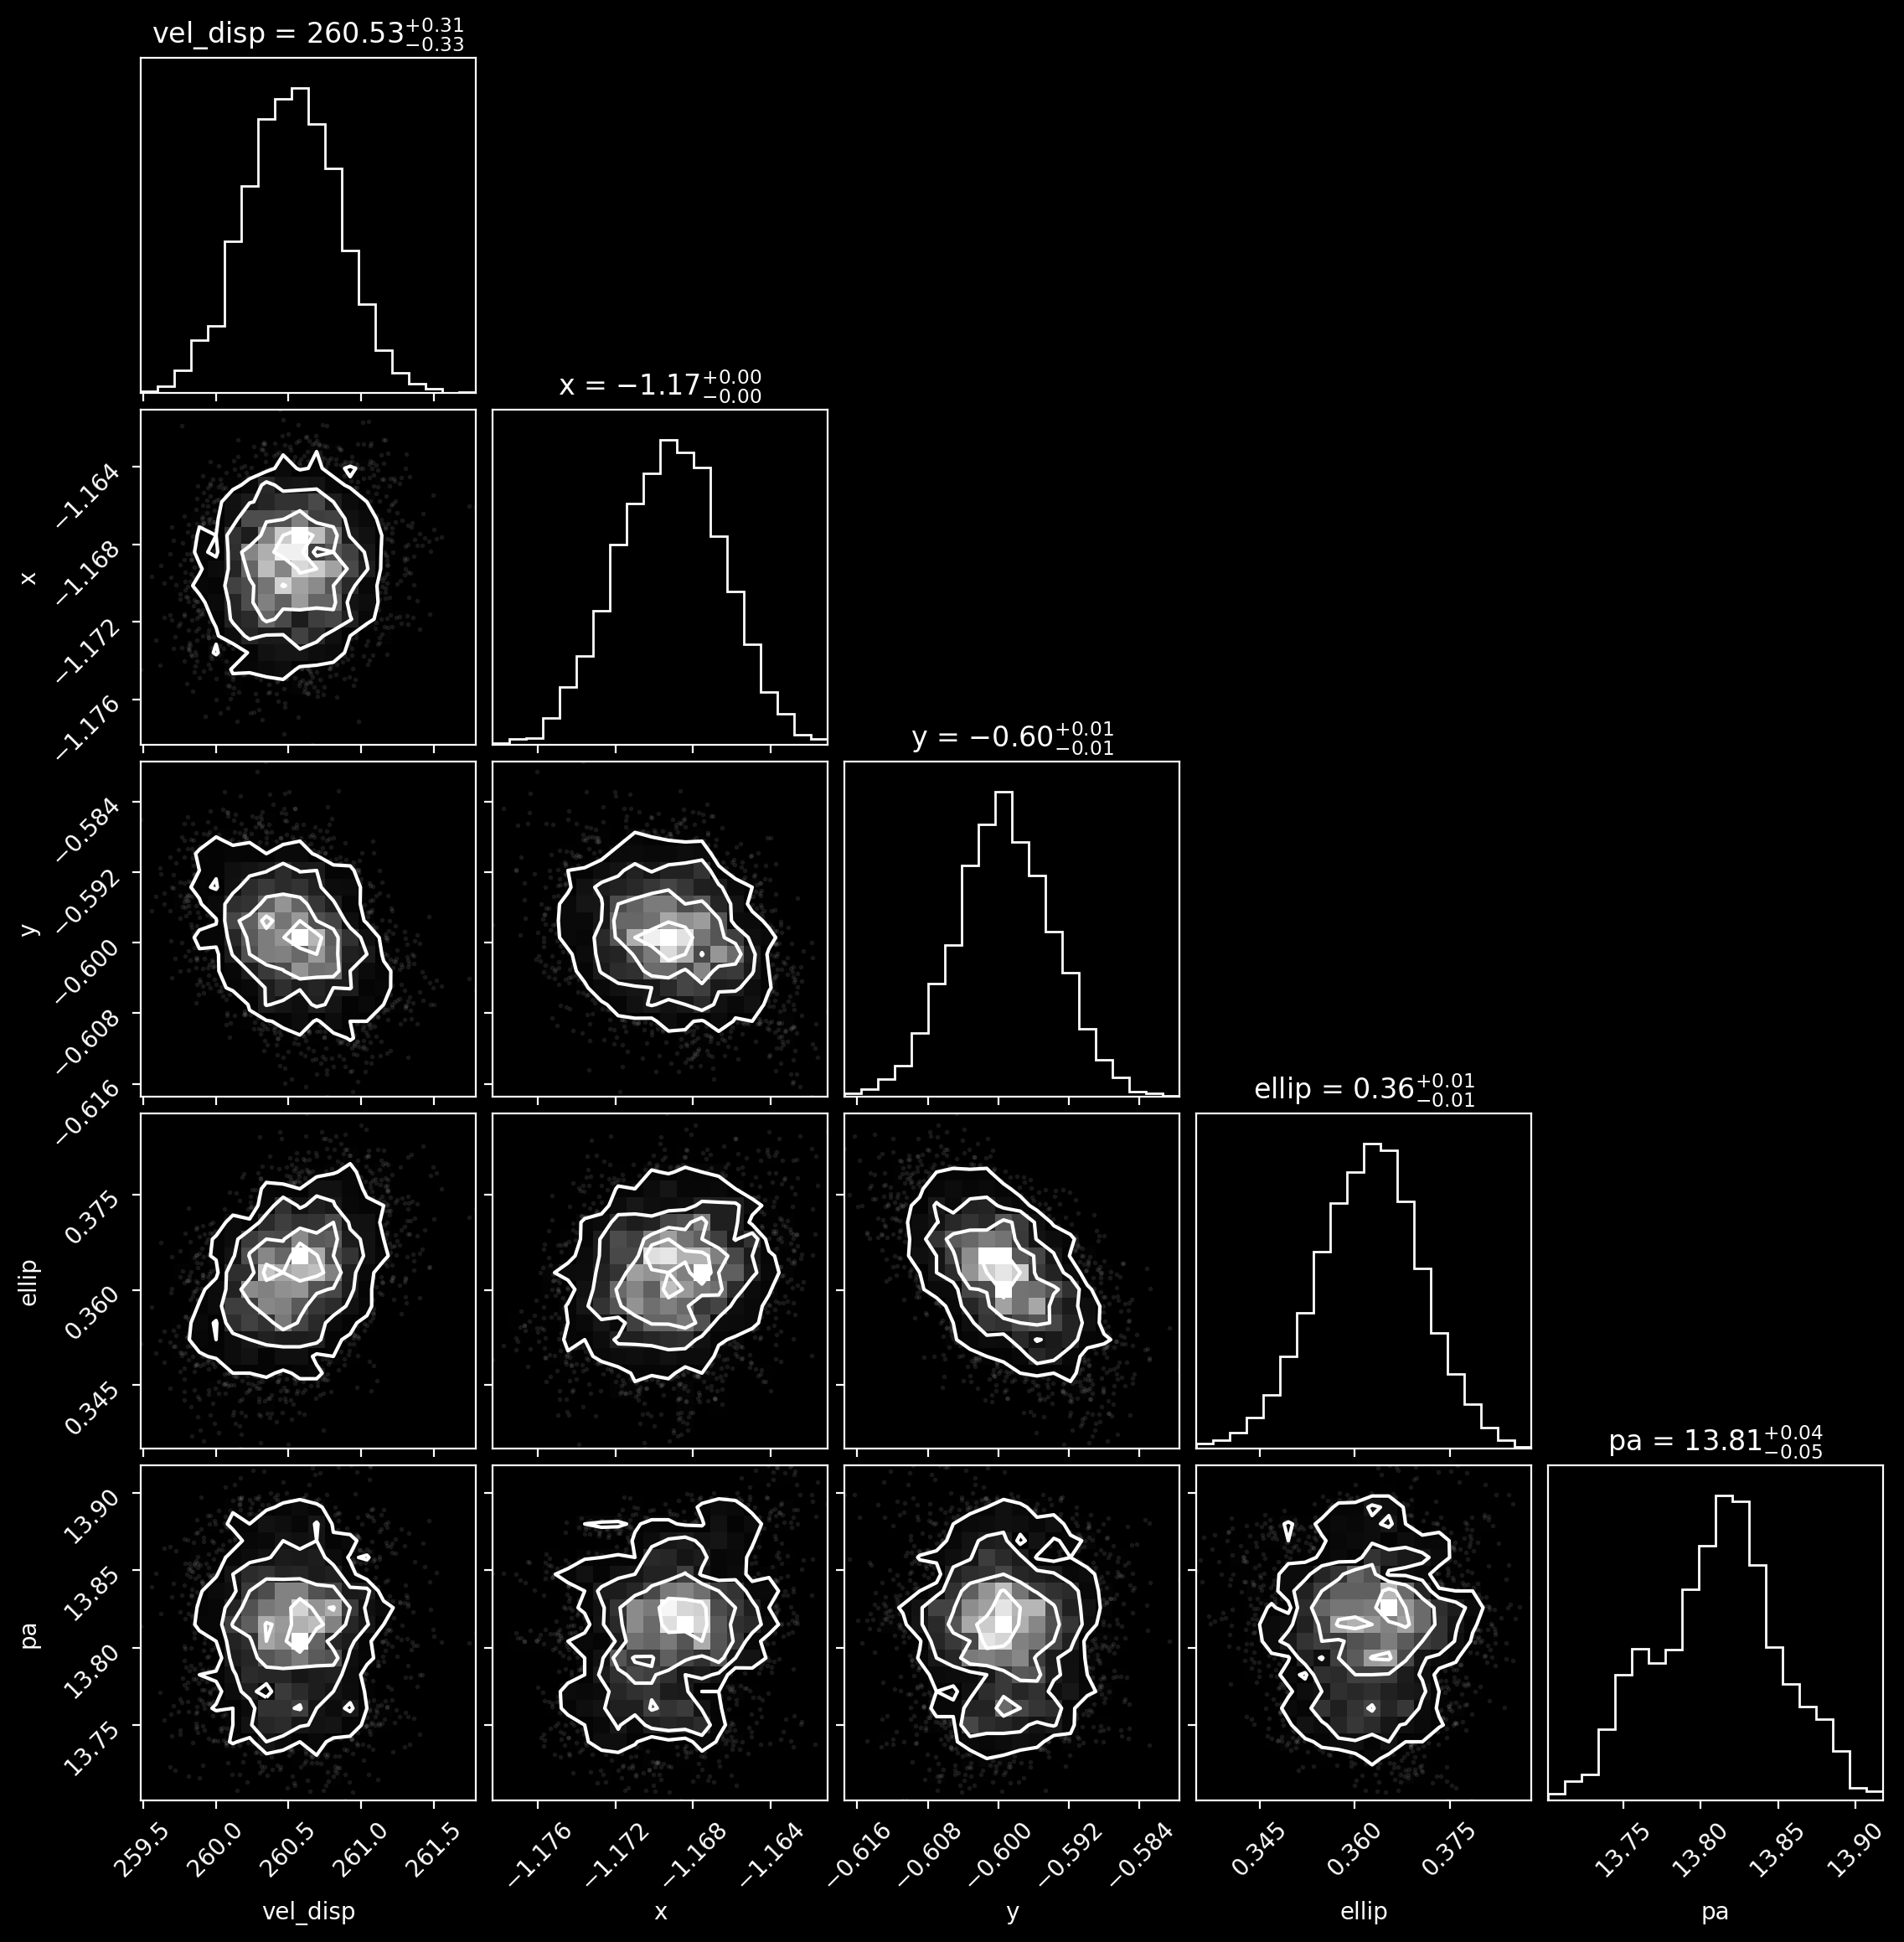

In [11]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')